<a href="https://colab.research.google.com/github/danielassaqovi/Daniel-PCVK_Ganjil_2026/blob/main/Minggu-1/latihan_integrasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
NIM = '244107020061'

# ===== AKSES DATASET DARI GOOGLE DRIVE =====
# Colab : tambahkan folder Drive yang dibagikan ke "My Drive"
#         (klik kanan folder > Add shortcut to Drive), lalu jalankan sel ini.
# Lokal : taruh folder dataset di ./PCVK (opsional).
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    _MYDRIVE = Path('/content/drive/MyDrive')
except Exception:
    _MYDRIVE = Path('.')


def _cari_dataset():
    kandidat = [_MYDRIVE / 'PCVK' / 'Images', _MYDRIVE / 'PCVK']
    for p in kandidat:
        if (p / 'lena.jpg').exists():
            return p
    try:
        for p in _MYDRIVE.rglob('lena.jpg'):
            return p.parent
    except Exception:
        pass
    return kandidat[0]


CONTOH = _cari_dataset()   # citra contoh bersama (lena.jpg, galaxy.jpg, noises/, ...)
BASE = CONTOH / NIM        # citra pribadi (KTM1a-d.jpg, OBJ1.jpg, NIGHT1.jpg)
if not (BASE / 'KTM1a.jpg').exists():
    BASE = CONTOH          # fallback ke citra contoh bila folder NIM belum ada

print('CONTOH :', CONTOH)
print('BASE   :', BASE)
print('Isi CONTOH:', sorted(p.name for p in CONTOH.iterdir())[:15])

Mounted at /content/drive
CONTOH : /content/drive/MyDrive/PCVK
BASE   : /content/drive/MyDrive/PCVK
Isi CONTOH: ['KTM.png', 'KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg', 'Salinan djawatan.jpg', 'citra_A_10x10.png', 'citra_B_10x10.png', 'djawatan.jpg', 'galaxy.jpg', 'lena.jpg', 'lena_lc.jpg', 'noises-20261002T162449Z-1-001']


### Integrasi
- Muhammad Daniel Assaqovi
- 244107020061

In [2]:
import numpy as np
import pandas as pd
import cv2 as cv
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg","https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"]

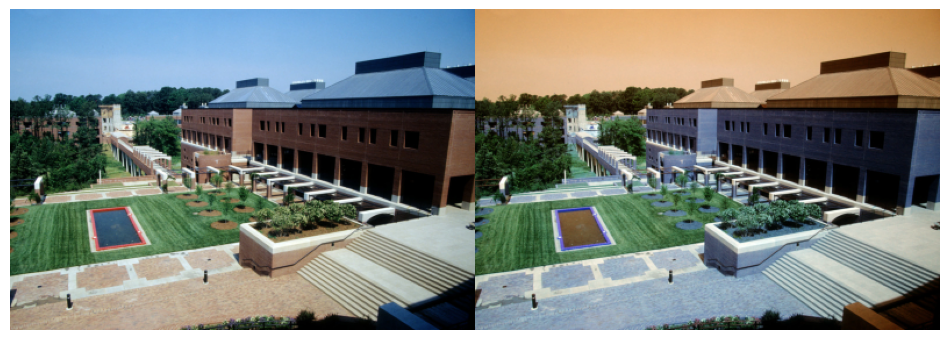

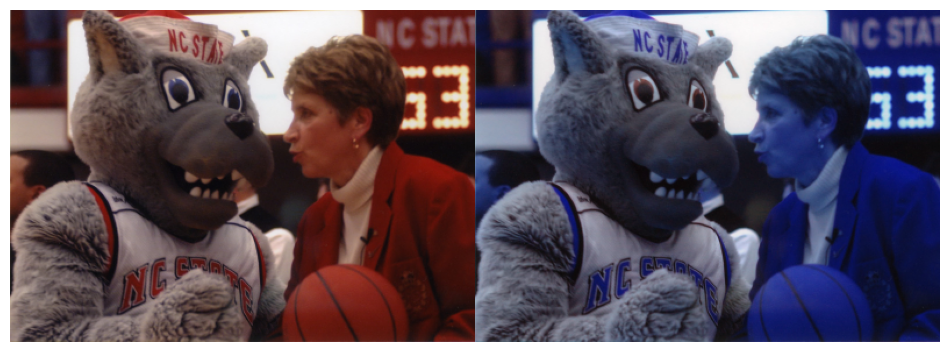

In [4]:
for url in urls:

    image = io.imread(url)

    # Resize
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)

    # Konversi warna
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    # Gabungkan horizontal
    final_frame = cv.hconcat((image, image_2))

    # Display
    plt.figure(figsize=(12, 5))
    plt.imshow(final_frame)
    plt.axis("off")
    plt.show()

    print("\n")

Resolusi Panjang X Lebar: 286 X 400


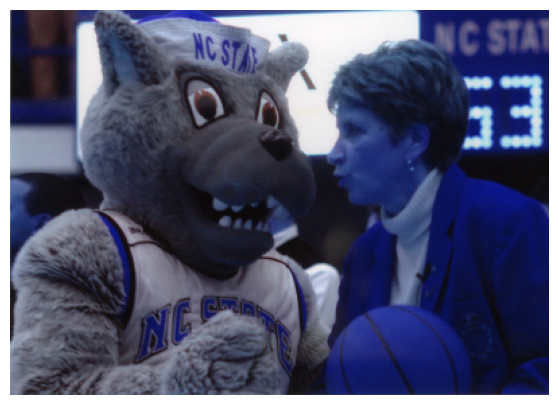

In [5]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]

print(f'Resolusi Panjang X Lebar: {tinggi} X {lebar}')

plt.figure(figsize=(12, 5))
plt.imshow(image_2)
plt.axis("off")
plt.show()

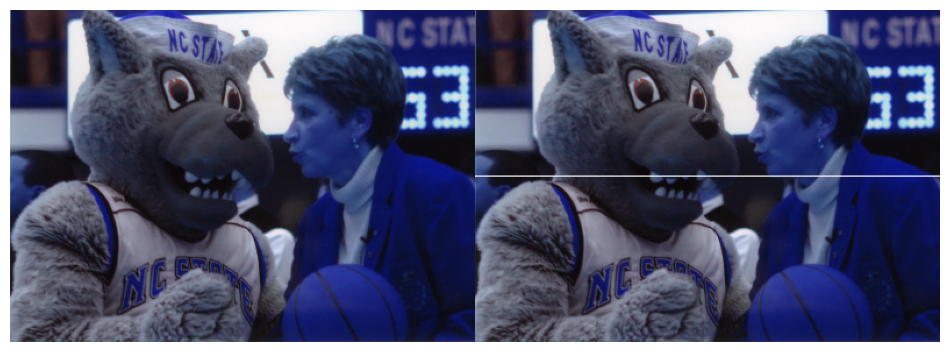

In [6]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#membuat garis horizontal ditengah image
for y in range (lebar):
    image_3 [int((tinggi)/2),y] = [255,255,255]

final_frame = cv.hconcat((image_2, image_3))

plt.figure(figsize=(12, 5))
plt.imshow(final_frame)
plt.axis("off")
plt.show()

### TUGAS PRAKTIKUM D2

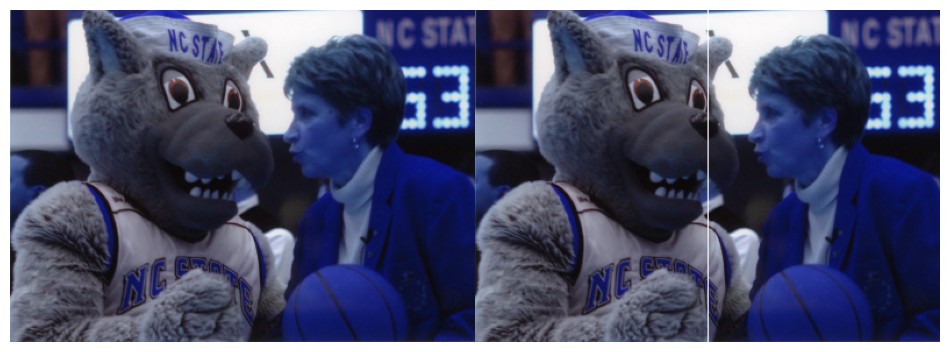

In [7]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#membuat garis Vertikal ditengah image
x = int(lebar / 2)

for y in range(tinggi):
    image_3[y, x] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))

plt.figure(figsize=(12, 5))
plt.imshow(final_frame)
plt.axis("off")
plt.show()

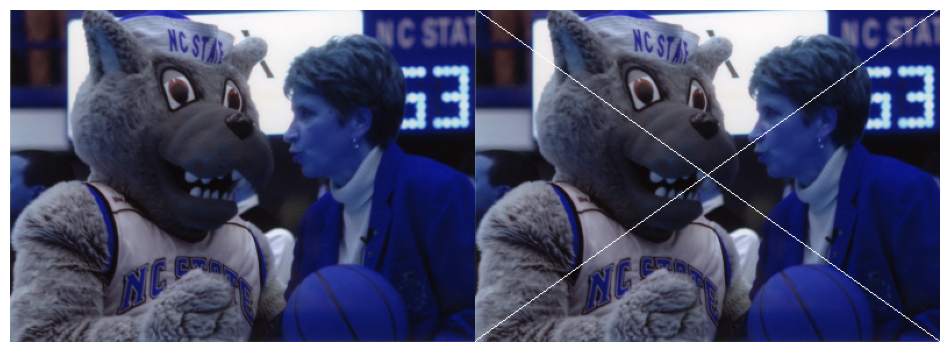

In [8]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

x = int(lebar / 2)

for x in range(lebar):
    y = int(tinggi - (x * tinggi / lebar) - 1)

    if 0 <= y < tinggi:
        image_3[y, x] = [255, 255, 255]

for x in range(lebar):
    y = int(x * tinggi / lebar)

    if 0 <= y < tinggi:
        image_3[y, x] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))

plt.figure(figsize=(12, 5))
plt.imshow(final_frame)
plt.axis("off")
plt.show()

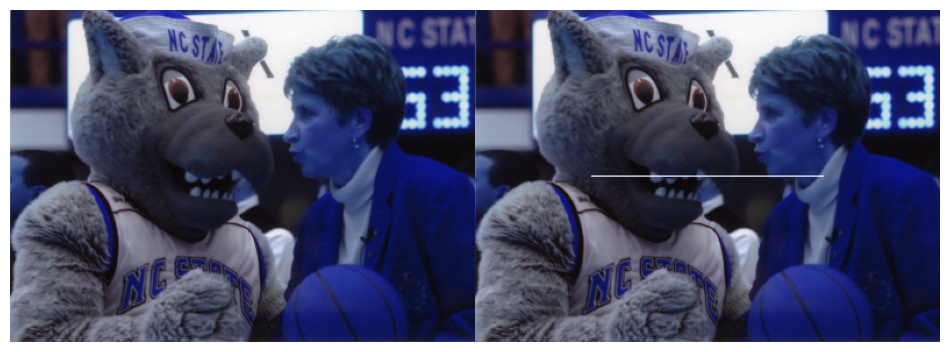

In [9]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

tinggi, lebar, _ = image_3.shape

panjang_garis = 200
y = tinggi // 2

x_awal = (lebar - panjang_garis) // 2
x_akhir = x_awal + panjang_garis

image_3[y, x_awal:x_akhir] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))

plt.figure(figsize=(12, 5))
plt.imshow(final_frame)
plt.axis("off")
plt.show()

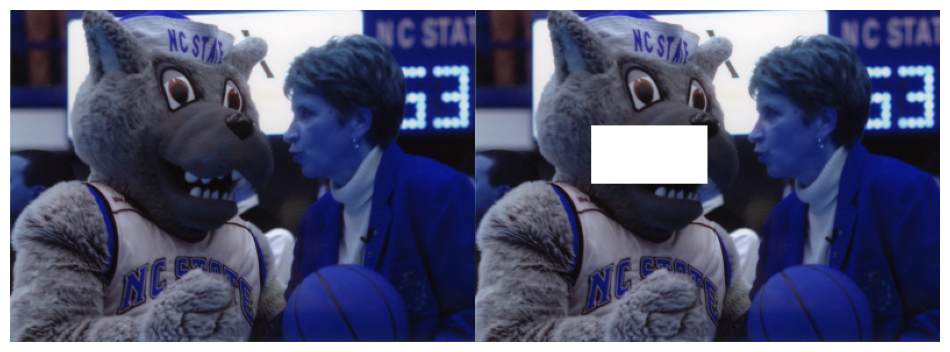

In [10]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

x_awal = 100
y_awal = 100

x_akhir = 200
y_akhir = 150

for y in range(y_awal, y_akhir):
    for x in range(x_awal, x_akhir):
        image_3[y, x] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))

plt.figure(figsize=(12, 5))
plt.imshow(final_frame)
plt.axis("off")
plt.show()

# Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi

## Pertanyaan

### 1. Google Colab

Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan menggunakan **Google Colab**?

### 2. Library pada Praktikum

Jelaskan mengenai kegunaan setiap **library** pada praktikum langkah ke-8.

Apakah semua library tersebut harus digunakan dalam praktikum sesi ini? Jelaskan!

### 3. Uji Coba Langkah ke-9

Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut:

```python
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)
```

Apa kegunaan kode program tersebut? Dan apa pengaruhnya jika kode tersebut tidak dilakukan?

### 4. Nilai `[255, 255, 255]`

Perhatikan potongan kode program berikut:

```python
for y in range (lebar):
    image_3 [int((tinggi)/2),y] = [255,255,255]
```

Apakah kegunaan kode:

```python
[255, 255, 255]
```

Jelaskan!

### 5. Pixel dan Resolusi Gambar

Jelaskan keterkaitan antara **pixel** dan **resolusi gambar**, baik pada gambar dengan resolusi tinggi maupun rendah.

## Jawaban

### 1.Google Colab
Karena Google Colab menyediakan GPU dan juga environment yang terinstall library yang dibutuhkan untuk praktikum ini.

### 2.Library pada Praktikum
- NumPy: mengolah array dan data numerik.
- Pandas: mengolah data berbentuk tabel.
- OpenCV: pengolahan dan manipulasi gambar.
- Scikit-image: pengolahan dan transformasi gambar.
- Pillow: membaca dan memanipulasi gambar.
- Matplotlib: menampilkan dan memvisualisasikan gambar.

### 3. Uji Coba Langkah ke-9

```python
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)
```

Kode tersebut mengecilkan ukuran gambar menjadi 50% dari ukuran awal.

### 4. Nilai `[255, 255, 255]`

Nilai [255, 255, 255] menunjukkan nilai tiga channel warna RGB. Karena semuanya bernilai 255, pixel tersebut berwarna putih.

### 5. Pixel dan Resolusi Gambar

Pixel adalah bagian terkecil penyusun gambar digital. Resolusi menunjukkan jumlah pixel pada gambar dalam bentuk lebar × tinggi.

Resolusi tinggi memiliki lebih banyak pixel sehingga detail gambar lebih tinggi, sedangkan resolusi rendah memiliki lebih sedikit pixel sehingga detail gambar lebih rendah.